# Workflows com LangGraph

Em um workflow a topologia do grafo está escrita no código, e o modelo decide o conteúdo de cada passo sem decidir o caminho. Este notebook monta os padrões dessa família: encadeamento, roteamento, paralelização, ciclo com verificação, subgrafos e orquestrador com trabalhadores.

In [1]:
# No Google Colab, descomente e rode uma vez.
# !pip install -q langchain langchain-openai langgraph

import operator
import time
from typing import Annotated, Literal

import pandas as pd
from IPython.display import Image
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

from langchain.chat_models import init_chat_model
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, Send

/home/silvan/anaconda3/lib/python3.10/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
model = init_chat_model("openai:gpt-4.1-mini", temperature=0.0)

TOPIC = "o elétron"

## Encadeamento

O encadeamento quebra a tarefa em passos, cada um com sua chamada, e passa a saída de um como entrada do seguinte. Entre dois passos cabe um gate: uma aresta condicional que confere o resultado do passo anterior e decide se o próximo precisa rodar.

In [3]:
class ExplainState(TypedDict):
    topic: str
    explanation: str
    improved_explanation: str

In [4]:
def generate_explanation(state: ExplainState) -> dict:
    """Escreve a primeira explicação do tópico."""
    msg = model.invoke(f"Explique {state['topic']} em duas frases, para quem não é da área.")
    return {"explanation": msg.content.strip()}


def verify_explanation(state: ExplainState) -> str:
    """Gate: verifica se a explicação traz algum número."""
    if any(char.isdigit() for char in state["explanation"]):
        return "Pass"
    return "Fail"


def add_data(state: ExplainState) -> dict:
    """Reescreve a explicação com um dado numérico concreto."""
    msg = model.invoke(f"Reescreva a explicação acrescentando um dado numérico concreto: {state['explanation']}")
    return {"improved_explanation": msg.content.strip()}

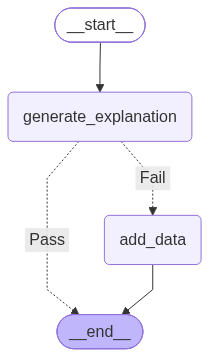

In [5]:
workflow = StateGraph(ExplainState)

# nós
workflow.add_node("generate_explanation", generate_explanation)
workflow.add_node("add_data", add_data)

# arestas
workflow.add_edge(START, "generate_explanation")
workflow.add_conditional_edges(
    "generate_explanation", verify_explanation, {"Fail": "add_data", "Pass": END}
)
workflow.add_edge("add_data", END)

chain = workflow.compile()
Image(chain.get_graph().draw_mermaid_png())

In [6]:
for topic in [TOPIC, "a velocidade da luz"]:
    state = chain.invoke({"topic": topic})
    print(topic, "|", verify_explanation(state), "|", sorted(state))
    print("  ", state.get("improved_explanation", state["explanation"])[:120])

o elétron | Fail | ['explanation', 'improved_explanation', 'topic']
   O elétron é uma partícula subatômica muito pequena, com uma carga elétrica negativa de aproximadamente -1,6 × 10⁻¹⁹ coul


a velocidade da luz | Pass | ['explanation', 'topic']
   A velocidade da luz é a rapidez com que a luz viaja no vácuo, aproximadamente 300.000 quilômetros por segundo. Isso sign


O elétron reprovou no gate, porque a primeira explicação não trouxe número nenhum, e seguiu para o `add_data`. A velocidade da luz passou direto para o fim, e a chave `improved_explanation` nem existe no resultado: o gate serve para não pagar por um passo que a saída anterior já dispensa.

### Exercício 1

Escreva um gate `verify_length`, que reprova a explicação com mais de 200 caracteres, e um nó `shorten`, que a reescreve mais curta e grava em `improved_explanation`. Monte o grafo com `generate_explanation`, o gate e o `shorten`, e rode com os dois tópicos. Qual deles reprovou, e quantos caracteres a versão encurtada tem?

In [7]:
# Seu código aqui

## Roteamento

O roteamento classifica a entrada e manda cada classe para um nó diferente. O nó classificador devolve um `Command`, que carrega no mesmo objeto a atualização do estado e o nome do destino, dispensando a aresta condicional.

In [8]:
class Kind(BaseModel):
    kind: Literal["definicao", "numero", "opiniao"]


class AskState(TypedDict):
    question: str
    kind: str
    answer: str

In [9]:
def classify(state: AskState) -> Command[Literal["explain", "estimate", "decline"]]:
    """Classifica a pergunta e segue direto para o nó correspondente."""
    kind = model.with_structured_output(Kind).invoke(state["question"]).kind
    goto = {"definicao": "explain", "numero": "estimate", "opiniao": "decline"}[kind]
    return Command(update={"kind": kind}, goto=goto)

In [10]:
def explain(state: AskState) -> dict:
    """Responde uma definição em uma frase."""
    return {"answer": model.invoke(f"Em uma frase: {state['question']}").content}


def estimate(state: AskState) -> dict:
    """Responde com o número e a unidade."""
    return {"answer": model.invoke(f"Responda só com número e unidade: {state['question']}").content}


def decline(state: AskState) -> dict:
    """Recusa pedidos de opinião."""
    return {"answer": "Fora do escopo de uma nota técnica."}

In [11]:
router_builder = StateGraph(AskState)

# nós
router_builder.add_node("classify", classify)
router_builder.add_node("explain", explain)
router_builder.add_node("estimate", estimate)
router_builder.add_node("decline", decline)

# arestas
router_builder.add_edge(START, "classify")

router = router_builder.compile()

In [12]:
questions = ["O que é um fóton?", "Qual a massa do elétron?", "Física é uma matéria difícil?"]

for question in questions:
    routed = router.invoke({"question": question})
    print(routed["kind"], "|", routed["answer"])

definicao | Um fóton é uma partícula elementar que representa a menor unidade de luz e outras radiações eletromagnéticas.


numero | 9,11 × 10⁻³¹ kg


opiniao | Fora do escopo de uma nota técnica.


As três perguntas caíram em três nós diferentes, e nenhuma aresta partindo de `classify` foi declarada. O destino veio do `goto`, e a anotação `Command[Literal[...]]` na assinatura informa ao grafo quais nós podem ser alcançados a partir dali.

### Exercício 2

Acrescente a classe `comparacao` ao `Kind`, um nó `compare` que responda comparações em duas frases, e o destino novo no `Literal` do `classify` e no mapa `goto`. Monte o roteador de novo e rode com duas perguntas de comparação, uma começando com "Compare" e outra com "Qual a diferença entre". As duas caíram na classe nova?

In [13]:
# Seu código aqui

## Paralelização

Vários nós ligados ao mesmo nó de origem rodam em paralelo, e isso se chama distribuição e agregação. Os três nós abaixo produzem coisas diferentes sobre o mesmo tópico, e um quarto nó reúne o resultado.

In [14]:
class StudyState(TypedDict):
    topic: str
    simple: str
    analogy: str
    question: str
    combined_output: str

In [15]:
def explain_simply(state: StudyState) -> dict:
    """Explica o tópico para uma criança de dez anos."""
    msg = model.invoke(f"Explique {state['topic']} para uma criança de dez anos, em duas frases.")
    return {"simple": msg.content.strip()}


def make_analogy(state: StudyState) -> dict:
    """Dá uma analogia do dia a dia para o tópico."""
    msg = model.invoke(f"Dê uma analogia do dia a dia para {state['topic']}, em uma frase.")
    return {"analogy": msg.content.strip()}


def write_question(state: StudyState) -> dict:
    """Escreve uma pergunta de prova sobre o tópico."""
    msg = model.invoke(f"Escreva uma pergunta de prova sobre {state['topic']}, sem a resposta.")
    return {"question": msg.content.strip()}

In [16]:
def aggregator(state: StudyState) -> dict:
    """Reúne as três saídas em um texto só, sem chamar o modelo."""
    combined = f"Material de estudo sobre {state['topic']}\n\n"
    combined += f"EM TERMOS SIMPLES:\n{state['simple']}\n\n"
    combined += f"ANALOGIA:\n{state['analogy']}\n\n"
    combined += f"PERGUNTA:\n{state['question']}"
    return {"combined_output": combined}

In [17]:
parallel_builder = StateGraph(StudyState)

# nós
parallel_builder.add_node("explain_simply", explain_simply)
parallel_builder.add_node("make_analogy", make_analogy)
parallel_builder.add_node("write_question", write_question)
parallel_builder.add_node("aggregator", aggregator)

# arestas
parallel_builder.add_edge(START, "explain_simply")
parallel_builder.add_edge(START, "make_analogy")
parallel_builder.add_edge(START, "write_question")
parallel_builder.add_edge("explain_simply", "aggregator")
parallel_builder.add_edge("make_analogy", "aggregator")
parallel_builder.add_edge("write_question", "aggregator")
parallel_builder.add_edge("aggregator", END)

parallel_workflow = parallel_builder.compile()

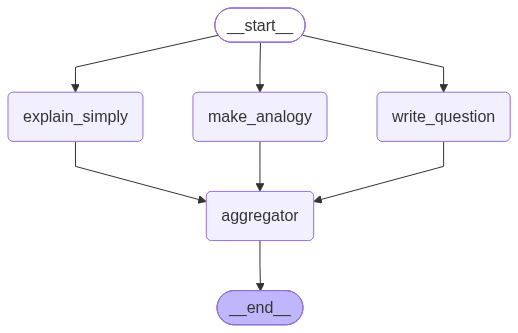

In [18]:
Image(parallel_workflow.get_graph().draw_mermaid_png())

In [19]:
state = parallel_workflow.invoke({"topic": TOPIC})

print(state["combined_output"])

Material de estudo sobre o elétron

EM TERMOS SIMPLES:
O elétron é uma partícula muito pequena que fica girando ao redor do centro dos átomos, que são como as pecinhas que formam tudo o que existe. Ele tem uma carga elétrica negativa, que ajuda a fazer a eletricidade funcionar e a manter as coisas juntas.

ANALOGIA:
O elétron é como uma abelha zumbindo ao redor da flor, sempre em movimento e essencial para a energia da colmeia.

PERGUNTA:
Explique a dualidade onda-partícula do elétron e descreva como esse conceito foi evidenciado experimentalmente.


Cada ramo escreveu em uma chave própria do estado, então nenhuma escrita concorreu com outra e o estado dispensa regra de combinação. O `aggregator` é o único nó que não chama o modelo: ele espera os três ramos terminarem e monta o texto com o que encontrou no estado.

### O ganho de tempo

Os três ramos são chamadas independentes, então rodá-los em paralelo custa o tempo do mais lento. A comparação abaixo mede o grafo contra as mesmas três chamadas feitas em sequência.

In [20]:
start = time.perf_counter()
parallel_workflow.invoke({"topic": TOPIC})
parallel_seconds = time.perf_counter() - start

start = time.perf_counter()
explain_simply({"topic": TOPIC})
make_analogy({"topic": TOPIC})
write_question({"topic": TOPIC})
serial_seconds = time.perf_counter() - start

pd.DataFrame([{"execução": "grafo", "segundos": round(parallel_seconds, 1)},
              {"execução": "sequência", "segundos": round(serial_seconds, 1)}])

,execução,segundos
0,grafo,1.0
1,sequência,2.2


A sequência custou perto da soma dos três ramos, e o grafo perto do maior deles. Paralelizar só paga quando os ramos não dependem um do outro: um passo que precisa do resultado anterior devolveria o mesmo tempo com mais código.

### Exercício 3

As funções abaixo já estão prontas: `define` escreve a definição do tópico, `simplify` e `translate` partem da definição e não dependem uma da outra, e `make_card` junta as três frases sem chamar o modelo. Monte o grafo em que a definição vem primeiro, os dois ramos rodam em paralelo depois dela e o cartão fecha, desenhe-o e rode com `TOPIC`. Quantas arestas o grafo tem?

In [21]:
class CardState(TypedDict):
    topic: str
    definition: str
    simple: str
    english: str
    card: str

In [22]:
def define(state: CardState) -> dict:
    """Define o tópico em uma frase."""
    return {"definition": model.invoke(f"Defina {state['topic']} em uma frase.").content.strip()}


def simplify(state: CardState) -> dict:
    """Reescreve a definição para uma criança."""
    request = f"Reescreva para uma criança de dez anos, em uma frase: {state['definition']}"
    return {"simple": model.invoke(request).content.strip()}


def translate(state: CardState) -> dict:
    """Traduz a definição para o inglês."""
    request = f"Traduza para o inglês, responda só com a tradução: {state['definition']}"
    return {"english": model.invoke(request).content.strip()}

In [23]:
def make_card(state: CardState) -> dict:
    """Junta as três frases em um cartão."""
    return {"card": f"{state['definition']}\nSimples: {state['simple']}\nEm inglês: {state['english']}"}

In [24]:
# Seu código aqui

## Ciclo com verificação

Uma aresta pode voltar para um nó anterior, e aí o grafo tem um laço. Um nó escreve, outro verifica as restrições e descreve o que falhou, e o texto volta para a escrita enquanto houver problema. O verificador é escrito em código, o que o deixa contar caracteres sem errar e sem gastar token.

In [25]:
class DraftState(TypedDict):
    topic: str
    note: str
    feedback: str
    attempts: int

In [26]:
def rewrite(state: DraftState) -> dict:
    """Escreve o parágrafo, incorporando o feedback quando houver."""
    request = f"Escreva um parágrafo de 200 a 240 caracteres sobre {state['topic']}. Responda só com o parágrafo."
    if state.get("feedback"):
        request += f"\n\nVersão anterior:\n{state['note']}\n\nProblemas: {state['feedback']}"
    return {"note": model.invoke(request).content.strip(), "attempts": state.get("attempts", 0) + 1}

In [27]:
def review(state: DraftState) -> dict:
    """Confere o tamanho e a palavra proibida, e descreve o que falhou."""
    note = state["note"]
    problems = []
    if not 200 <= len(note) <= 240:
        problems.append(f"tem {len(note)} caracteres em vez de 200 a 240")
    if "sustentável" in note.lower():
        problems.append("usa a palavra sustentável")
    return {"feedback": "; ".join(problems)}


def again(state: DraftState) -> Literal["rewrite", END]:
    """Reescreve enquanto houver problema e restar tentativa."""
    if not state["feedback"] or state["attempts"] >= 3:
        return END
    return "rewrite"

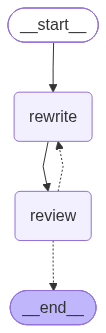

In [28]:
writer_builder = StateGraph(DraftState)

# nós
writer_builder.add_node("rewrite", rewrite)
writer_builder.add_node("review", review)

# arestas
writer_builder.add_edge(START, "rewrite")
writer_builder.add_edge("rewrite", "review")
writer_builder.add_conditional_edges("review", again, ["rewrite", END])

writer = writer_builder.compile()
Image(writer.get_graph().draw_mermaid_png())

In [29]:
for step in writer.stream({"topic": TOPIC}, stream_mode="updates"):
    node, update = next(iter(step.items()))
    print(node, "|", update)

rewrite | {'note': 'O elétron é uma partícula subatômica com carga negativa, fundamental na estrutura dos átomos. Ele orbita o núcleo e participa das ligações químicas, influenciando propriedades elétricas e magnéticas da matéria.', 'attempts': 1}
review | {'feedback': ''}


Cada volta corrige o problema que o revisor apontou, e o feedback vazio é o que libera a saída. O `attempts` é o limite do laço: sem ele, uma restrição que o modelo nunca satisfaz roda para sempre, e com ele o grafo entrega o último rascunho mesmo reprovado.

### Exercício 4

Acrescente ao `review` uma terceira regra, o parágrafo não pode conter a palavra "carga", compile o `writer` de novo e rode com `TOPIC` e `stream_mode="updates"`. Quantas voltas o laço deu até aprovar, ou ele parou no limite de tentativas?

In [30]:
# Seu código aqui

## Subgrafos

Um grafo compilado é um runnable, e por isso pode entrar como nó de outro grafo. As chaves em comum entre os dois estados são o que atravessa a fronteira, e as chaves que só existem no subgrafo ficam contidas nele.

In [32]:
class PageState(TypedDict):
    topic: str
    note: str
    headline: str

In [33]:
def headline(state: PageState) -> dict:
    """Escreve a manchete a partir do parágrafo aprovado."""
    request = f"Escreva uma manchete de até 50 caracteres para:\n{state['note']}"
    return {"headline": model.invoke(request).content.strip()}

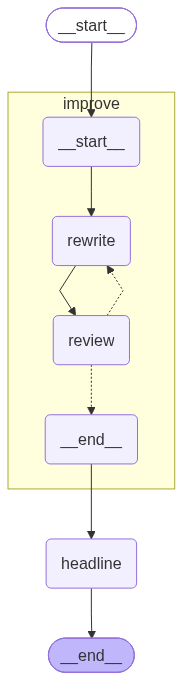

In [34]:
page_builder = StateGraph(PageState)

# nós, e o grafo compilado entra como um deles
page_builder.add_node("improve", writer)
page_builder.add_node("headline", headline)

# arestas
page_builder.add_edge(START, "improve")
page_builder.add_edge("improve", "headline")

page = page_builder.compile()
Image(page.get_graph(xray=1).draw_mermaid_png())

In [35]:
published = page.invoke({"topic": TOPIC})

print(published["headline"])
print(sorted(published))

Elétron: partícula chave na estrutura atômica
['headline', 'note', 'topic']


O `xray=1` desenha o subgrafo aberto dentro do nó `improve`. As chaves `feedback` e `attempts` não aparecem no resultado porque não fazem parte do `PageState`: o ciclo de revisão as usou e as deixou para trás.

### Exercício 5

Use o `router` compilado como nó de um grafo novo, cujo estado tem `question`, `answer` e `answer_length`, com um segundo nó que preenche `answer_length` com o tamanho da resposta. Rode com uma pergunta escrita por você. Quais chaves do `AskState` atravessaram para o resultado final, e qual ficou dentro do subgrafo?

In [36]:
# Seu código aqui

## Orquestrador com trabalhadores

Quando a quantidade de ramos só se conhece em tempo de execução, as arestas não cabem no código. O `Send` resolve isso: um nó devolve uma lista de `Send`, cada um com o nome do nó de destino e o estado daquele ramo.

In [37]:
class Plan(BaseModel):
    sections: list[str] = Field(description="Títulos das seções, de três a quatro")


class ReportState(TypedDict):
    topic: str
    sections: list[str]
    parts: Annotated[list, operator.add]


class SectionState(TypedDict):
    topic: str
    section: str

In [38]:
def plan(state: ReportState) -> dict:
    """Decide as seções do relatório."""
    request = f"Liste as seções de um relatório curto sobre {state['topic']}."
    return {"sections": model.with_structured_output(Plan).invoke(request).sections}


def dispatch(state: ReportState) -> list[Send]:
    """Abre um trabalhador por seção planejada."""
    return [Send("write_section", {"topic": state["topic"], "section": title}) for title in state["sections"]]


def write_section(state: SectionState) -> dict:
    """Escreve uma seção em duas frases."""
    request = f"Escreva duas frases sobre {state['section']}, em um relatório sobre {state['topic']}."
    return {"parts": [f"{state['section']}: {model.invoke(request).content}"]}

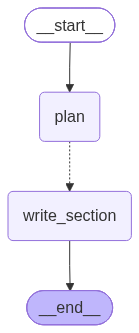

In [39]:
report_builder = StateGraph(ReportState)

# nós
report_builder.add_node("plan", plan)
report_builder.add_node("write_section", write_section)

# arestas
report_builder.add_edge(START, "plan")
report_builder.add_conditional_edges("plan", dispatch, ["write_section"])
report_builder.add_edge("write_section", END)

orchestrator = report_builder.compile()
Image(orchestrator.get_graph().draw_mermaid_png())

In [40]:
report = orchestrator.invoke({"topic": TOPIC})

print(len(report["parts"]))
for part in report["parts"]:
    print(part)

4
Introdução: O elétron é uma partícula subatômica fundamental, com carga elétrica negativa, que desempenha um papel crucial na estrutura dos átomos e nas interações eletromagnéticas. Este relatório tem como objetivo apresentar as principais características do elétron, sua descoberta e sua importância na física moderna.
Propriedades do Elétron: O elétron é uma partícula subatômica com carga elétrica negativa elementar, aproximadamente igual a -1,6 × 10⁻¹⁹ coulombs. Além disso, possui uma massa muito pequena, cerca de 9,11 × 10⁻³¹ quilogramas, o que contribui para sua alta mobilidade em campos elétricos e magnéticos.
Importância na Física: O elétron é fundamental para a compreensão dos fenômenos elétricos e magnéticos, sendo uma das partículas básicas que compõem a matéria. Seu estudo permite o desenvolvimento de tecnologias essenciais, como dispositivos eletrônicos e sistemas de comunicação.
Conclusão: A conclusão do relatório destaca a importância do elétron como partícula fundamental

A quantidade de trabalhadores veio do `plan`, e o `SectionState` mostra que cada ramo recebeu um estado próprio em vez do estado do grafo. O desenho traz uma caixa só para `write_section`, porque a quantidade de cópias não existe no momento da compilação.

### Exercício 6

Acrescente ao `ReportState` uma chave `note` e ao orquestrador um nó `synthesize`, depois de `write_section`, que junte as partes em um texto corrido com uma chamada ao modelo e grave em `note`. Rode com `TOPIC`. Quantas seções o `plan` abriu, e quantas chamadas ao modelo o grafo inteiro fez, contando a síntese?

In [41]:
# Seu código aqui